# 4. Классификация.

Упражнения из **4 главы** книги [Введение в статистическое обучение](http://www-bcf.usc.edu/~gareth/ISL/) Гарета Джеймса, Даниела Уиттена, Тревора Хасти, Роберта Тибширани, Джонатана Тейлора.

## Практические задания.

### Задание 13.

Это упражнение построено на основе набора данных Weekly, входящего в состав пакета ISLP.

(a) Проведите числовое и графическо исследования данных в наборе Weekly. Есть ли в данных какие-то повторяющиесы шаблоны.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize)

In [3]:
from ISLP import confusion_table
from ISLP.models import contrast
from sklearn.discriminant_analysis import \
(LinearDiscriminantAnalysis as LDA, 
QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [4]:
weekly = load_data('Weekly')

In [5]:
weekly.describe()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000
mean,2000.048669,0.150585,0.151079,0.147205,0.145818,0.139893,1.574618,0.149899
std,6.033182,2.357013,2.357254,2.360502,2.360279,2.361285,1.686636,2.356927
min,1990.000000,-18.195000,-18.195000,-18.195000,-18.195000,-18.195000,0.087465,-18.195000
25%,1995.000000,-1.154000,-1.154000,-1.158000,-1.158000,-1.166000,0.332022,-1.154000
50%,2000.000000,0.241000,0.241000,0.241000,0.238000,0.234000,1.002680,0.241000
75%,2005.000000,1.405000,1.409000,1.409000,1.409000,1.405000,2.053727,1.405000
max,2010.000000,12.026000,12.026000,12.026000,12.026000,12.026000,9.328214,12.026000


In [6]:
weekly.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


In [7]:
weekly.drop(labels = 'Direction', axis = 1).corr()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000000,-0.032289,-0.033390,-0.030006,-0.031128,-0.030519,0.841942,-0.032460
Lag1,-0.032289,1.000000,-0.074853,0.058636,-0.071274,-0.008183,-0.064951,-0.075032
Lag2,-0.033390,-0.074853,1.000000,-0.075721,0.058382,-0.072499,-0.085513,0.059167
Lag3,-0.030006,0.058636,-0.075721,1.000000,-0.075396,0.060657,-0.069288,-0.071244
Lag4,-0.031128,-0.071274,0.058382,-0.075396,1.000000,-0.075675,-0.061075,-0.007826
Lag5,-0.030519,-0.008183,-0.072499,0.060657,-0.075675,1.000000,-0.058517,0.011013
Volume,0.841942,-0.064951,-0.085513,-0.069288,-0.061075,-0.058517,1.000000,-0.033078
Today,-0.032460,-0.075032,0.059167,-0.071244,-0.007826,0.011013,-0.033078,1.000000


<Axes: >

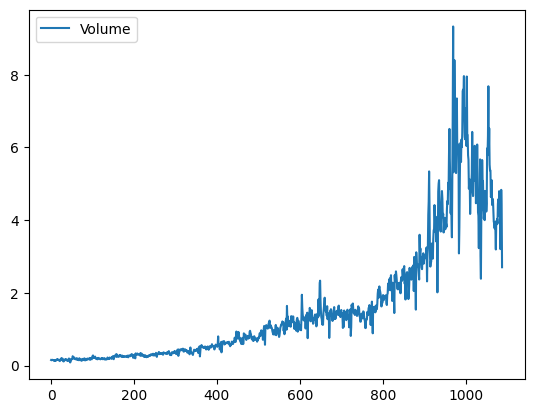

In [8]:
weekly.plot(y = 'Volume')

(b) Выполните подгонку модели логистической регресси ко всему набору данных, используя в качестве откилка переменную Direction, а в качестве предикторов - все переменные Lag, а также переменную Volume

In [9]:
X = weekly.drop(labels = ['Year', 'Direction', 'Today'], axis = 1)
y = pd.get_dummies(weekly['Direction'], drop_first = True)

In [10]:
X.head()

,Lag1,Lag2,Lag3,Lag4,Lag5,Volume
0,0.816,1.572,-3.936,-0.229,-3.484,0.154976
1,-0.270,0.816,1.572,-3.936,-0.229,0.148574
2,-2.576,-0.270,0.816,1.572,-3.936,0.159837
3,3.514,-2.576,-0.270,0.816,1.572,0.161630
4,0.712,3.514,-2.576,-0.270,0.816,0.153728


In [11]:
design = MS(X.columns)

In [12]:
X = design.fit_transform(X)

In [13]:
y.head()

,Up
0,False
1,False
2,True
3,True
4,True


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [15]:
ln_model = sm.Logit(y_train, X_train)
ln_result = ln_model.fit()

Optimization terminated successfully.
         Current function value: 0.683018
         Iterations 4


In [16]:
print(ln_result.summary())

                           Logit Regression Results                           
Dep. Variable:                     Up   No. Observations:                  762
Model:                          Logit   Df Residuals:                      755
Method:                           MLE   Df Model:                            6
Date:                Mon, 04 Nov 2024   Pseudo R-squ.:                 0.01018
Time:                        17:10:59   Log-Likelihood:                -520.46
converged:                       True   LL-Null:                       -525.81
Covariance Type:            nonrobust   LLR p-value:                   0.09786
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2220      0.103      2.157      0.031       0.020       0.424
Lag1          -0.0486      0.032     -1.534      0.125      -0.111       0.014
Lag2           0.0657      0.031      2.093      0.0

Только Lag2, является статистическим значимым

(с) Сформируйте матрицу неточностеей и вычислите общую долю правильных предсказаний.

In [17]:
pred_y = ln_result.predict(X_test)

In [18]:
pred_y

355     0.507178
56      0.525612
478     0.514344
566     0.693140
1066    0.486975
          ...   
1049    0.478246
782     0.600683
305     0.572120
717     0.549620
906     0.506348
Length: 327, dtype: float64

In [19]:
labels = pred_y > 0.5

In [20]:
print('Accuracy:', np.mean(labels == y_test['Up']))

Accuracy: 0.5474006116207951


In [21]:
from sklearn.metrics import classification_report

In [22]:
confusion_table(labels, y_test)

Truth,False,True
Predicted,,
False,24,39
True,109,155


In [23]:
print(classification_report(y_test, labels))

              precision    recall  f1-score   support

       False       0.38      0.18      0.24       133
        True       0.59      0.80      0.68       194

    accuracy                           0.55       327
   macro avg       0.48      0.49      0.46       327
weighted avg       0.50      0.55      0.50       327



Видно, что для модели характерны ложно положительная ошибка.

(d) Теперь выполните подгонку модели логистической регресси с только с lag2 в качестве предиктора.

In [24]:
ln_model = sm.Logit(y_train, X_train[['intercept','Lag2']])
ln_result = ln_model.fit()

Optimization terminated successfully.
         Current function value: 0.686764
         Iterations 4


In [25]:
print(ln_result.summary())

                           Logit Regression Results                           
Dep. Variable:                     Up   No. Observations:                  762
Model:                          Logit   Df Residuals:                      760
Method:                           MLE   Df Model:                            1
Date:                Mon, 04 Nov 2024   Pseudo R-squ.:                0.004753
Time:                        17:10:59   Log-Likelihood:                -523.31
converged:                       True   LL-Null:                       -525.81
Covariance Type:            nonrobust   LLR p-value:                   0.02538
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.1491      0.073      2.042      0.041       0.006       0.292
Lag2           0.0680      0.031      2.207      0.027       0.008       0.128


In [26]:
pred_y = ln_result.predict(X_test[['intercept','Lag2']])

In [27]:
labels = pred_y > 0.5

In [28]:
print('Accuracy:', np.mean(labels == y_test['Up']))

Accuracy: 0.5963302752293578


In [29]:
confusion_table(labels, y_test)

Truth,False,True
Predicted,,
False,18,17
True,115,177


In [30]:
print(classification_report(y_test, labels))

              precision    recall  f1-score   support

       False       0.51      0.14      0.21       133
        True       0.61      0.91      0.73       194

    accuracy                           0.60       327
   macro avg       0.56      0.52      0.47       327
weighted avg       0.57      0.60      0.52       327



(e) Повторите пунк (d) с использованием LDA.

In [31]:
lda = LDA(store_covariance = True)

In [32]:
lda.fit(X_train.drop(X_train.columns[X_train.columns != 'Lag2'], axis = 1), y_train)

C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LinearDiscriminantAnalysis(store_covariance=True)

In [33]:
pred_y = lda.predict(X_test.drop(X_train.columns[X_train.columns != 'Lag2'], axis = 1))

In [34]:
print('Accuracy:', np.mean(labels == y_test['Up']))

Accuracy: 0.5963302752293578


In [35]:
confusion_table(labels, y_test)

Truth,False,True
Predicted,,
False,18,17
True,115,177


In [36]:
print(classification_report(y_test, labels))

              precision    recall  f1-score   support

       False       0.51      0.14      0.21       133
        True       0.61      0.91      0.73       194

    accuracy                           0.60       327
   macro avg       0.56      0.52      0.47       327
weighted avg       0.57      0.60      0.52       327



(f) Повторите пунку (D) c использованием QDA.

In [37]:
qda = QDA(store_covariance = True)

In [38]:
qda.fit(X_train.drop(X_train.columns[X_train.columns != 'Lag2'], axis = 1), y_train)

C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


QuadraticDiscriminantAnalysis(store_covariance=True)

In [39]:
pred_y = qda.predict(X_test.drop(X_train.columns[X_train.columns != 'Lag2'], axis = 1))

In [40]:
print('Accuracy:', np.mean(labels == y_test['Up']))

Accuracy: 0.5963302752293578


In [41]:
confusion_table(labels, y_test)

Truth,False,True
Predicted,,
False,18,17
True,115,177


In [42]:
print(classification_report(y_test, labels))

              precision    recall  f1-score   support

       False       0.51      0.14      0.21       133
        True       0.61      0.91      0.73       194

    accuracy                           0.60       327
   macro avg       0.56      0.52      0.47       327
weighted avg       0.57      0.60      0.52       327



(g) Повторите пунк (d) с использованием KNN c K = 1.

In [43]:
from sklearn.neighbors import KNeighborsClassifier

In [44]:
knn = KNeighborsClassifier(n_neighbors=1)

In [45]:
knn.fit(X_train.drop(X_train.columns[X_train.columns != 'Lag2'], axis = 1), y_train)

C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\neighbors\_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(n_neighbors=1)

In [46]:
pred_y = knn.predict(X_test.drop(X_train.columns[X_train.columns != 'Lag2'], axis = 1))

In [47]:
labels = pred_y

In [48]:
print('Accuracy:', np.mean(labels == y_test['Up']))

Accuracy: 0.4923547400611621


In [49]:
confusion_table(labels, y_test)

Truth,False,True
Predicted,,
False,72,105
True,61,89


In [50]:
print(classification_report(y_test, labels))

              precision    recall  f1-score   support

       False       0.41      0.54      0.46       133
        True       0.59      0.46      0.52       194

    accuracy                           0.49       327
   macro avg       0.50      0.50      0.49       327
weighted avg       0.52      0.49      0.50       327



(h) Повторите пункт (d) с использованием наивного байесовского классификатора.

In [51]:
NB = GaussianNB()

In [52]:
NB.fit(X_train.drop(X_train.columns[X_train.columns != 'Lag2'], axis = 1), y_train)

C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GaussianNB()

In [53]:
labels = NB.predict(X_test.drop(X_train.columns[X_train.columns != 'Lag2'], axis = 1))

In [54]:
print('Accuracy:', np.mean(labels == y_test['Up']))

Accuracy: 0.5963302752293578


In [55]:
confusion_table(labels, y_test)

Truth,False,True
Predicted,,
False,18,17
True,115,177


In [56]:
print(classification_report(y_test, labels))

              precision    recall  f1-score   support

       False       0.51      0.14      0.21       133
        True       0.61      0.91      0.73       194

    accuracy                           0.60       327
   macro avg       0.56      0.52      0.47       327
weighted avg       0.57      0.60      0.52       327



(i) Какой классификатор покзал лучший результат?

> Лучше всего себя показали следующие классификаторы: линейный классификатор, LDA, QDA, наивный Байес.

## Задание 14.

В этом упражнении вы разработаете моедль для предсказания того, будет ли показатель пробега для заданного автомоблия высоким или низким, основываясь на наборе данных Auto

(a) Создайте бинарную перменную октлика mpg01, которая будет содержать единицу, если значение mpg первышает медину по этому столбцу, и ноль в остальных.

In [58]:
Auto = load_data('Auto')

In [59]:
Auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


In [63]:
mpg01 = Auto['mpg'] > Auto['mpg'].median()

In [72]:
mpg01 = mpg01.astype(int)

In [73]:
Auto['mpg1'] = mpg01

In [74]:
mpg01

name
chevrolet chevelle malibu    0
buick skylark 320            0
plymouth satellite           0
amc rebel sst                0
ford torino                  0
                            ..
ford mustang gl              1
vw pickup                    1
dodge rampage                1
ford ranger                  1
chevy s-10                   1
Name: mpg, Length: 392, dtype: int32

In [75]:
Auto = Auto.drop('mpg', axis = 1)

In [76]:
Auto.head()

,cylinders,displacement,horsepower,weight,acceleration,year,origin,mpg1
name,,,,,,,,
chevrolet chevelle malibu,8,307.0,130,3504,12.0,70,1,0
buick skylark 320,8,350.0,165,3693,11.5,70,1,0
plymouth satellite,8,318.0,150,3436,11.0,70,1,0
amc rebel sst,8,304.0,150,3433,12.0,70,1,0
ford torino,8,302.0,140,3449,10.5,70,1,0


(b) Исследуйте данные.

In [77]:
Auto.describe()

,cylinders,displacement,horsepower,weight,acceleration,year,origin,mpg1
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531,0.500000
std,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518,0.500639
min,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000,0.000000
25%,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000,0.000000
50%,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000,0.500000
75%,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000,1.000000
max,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000,1.000000


In [78]:
Auto.corr()

,cylinders,displacement,horsepower,weight,acceleration,year,origin,mpg1
cylinders,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932,-0.759194
displacement,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535,-0.753477
horsepower,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171,-0.667053
weight,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005,-0.757757
acceleration,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746,0.346822
year,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528,0.429904
origin,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000,0.513698
mpg1,-0.759194,-0.753477,-0.667053,-0.757757,0.346822,0.429904,0.513698,1.000000


In [80]:
import seaborn as sns

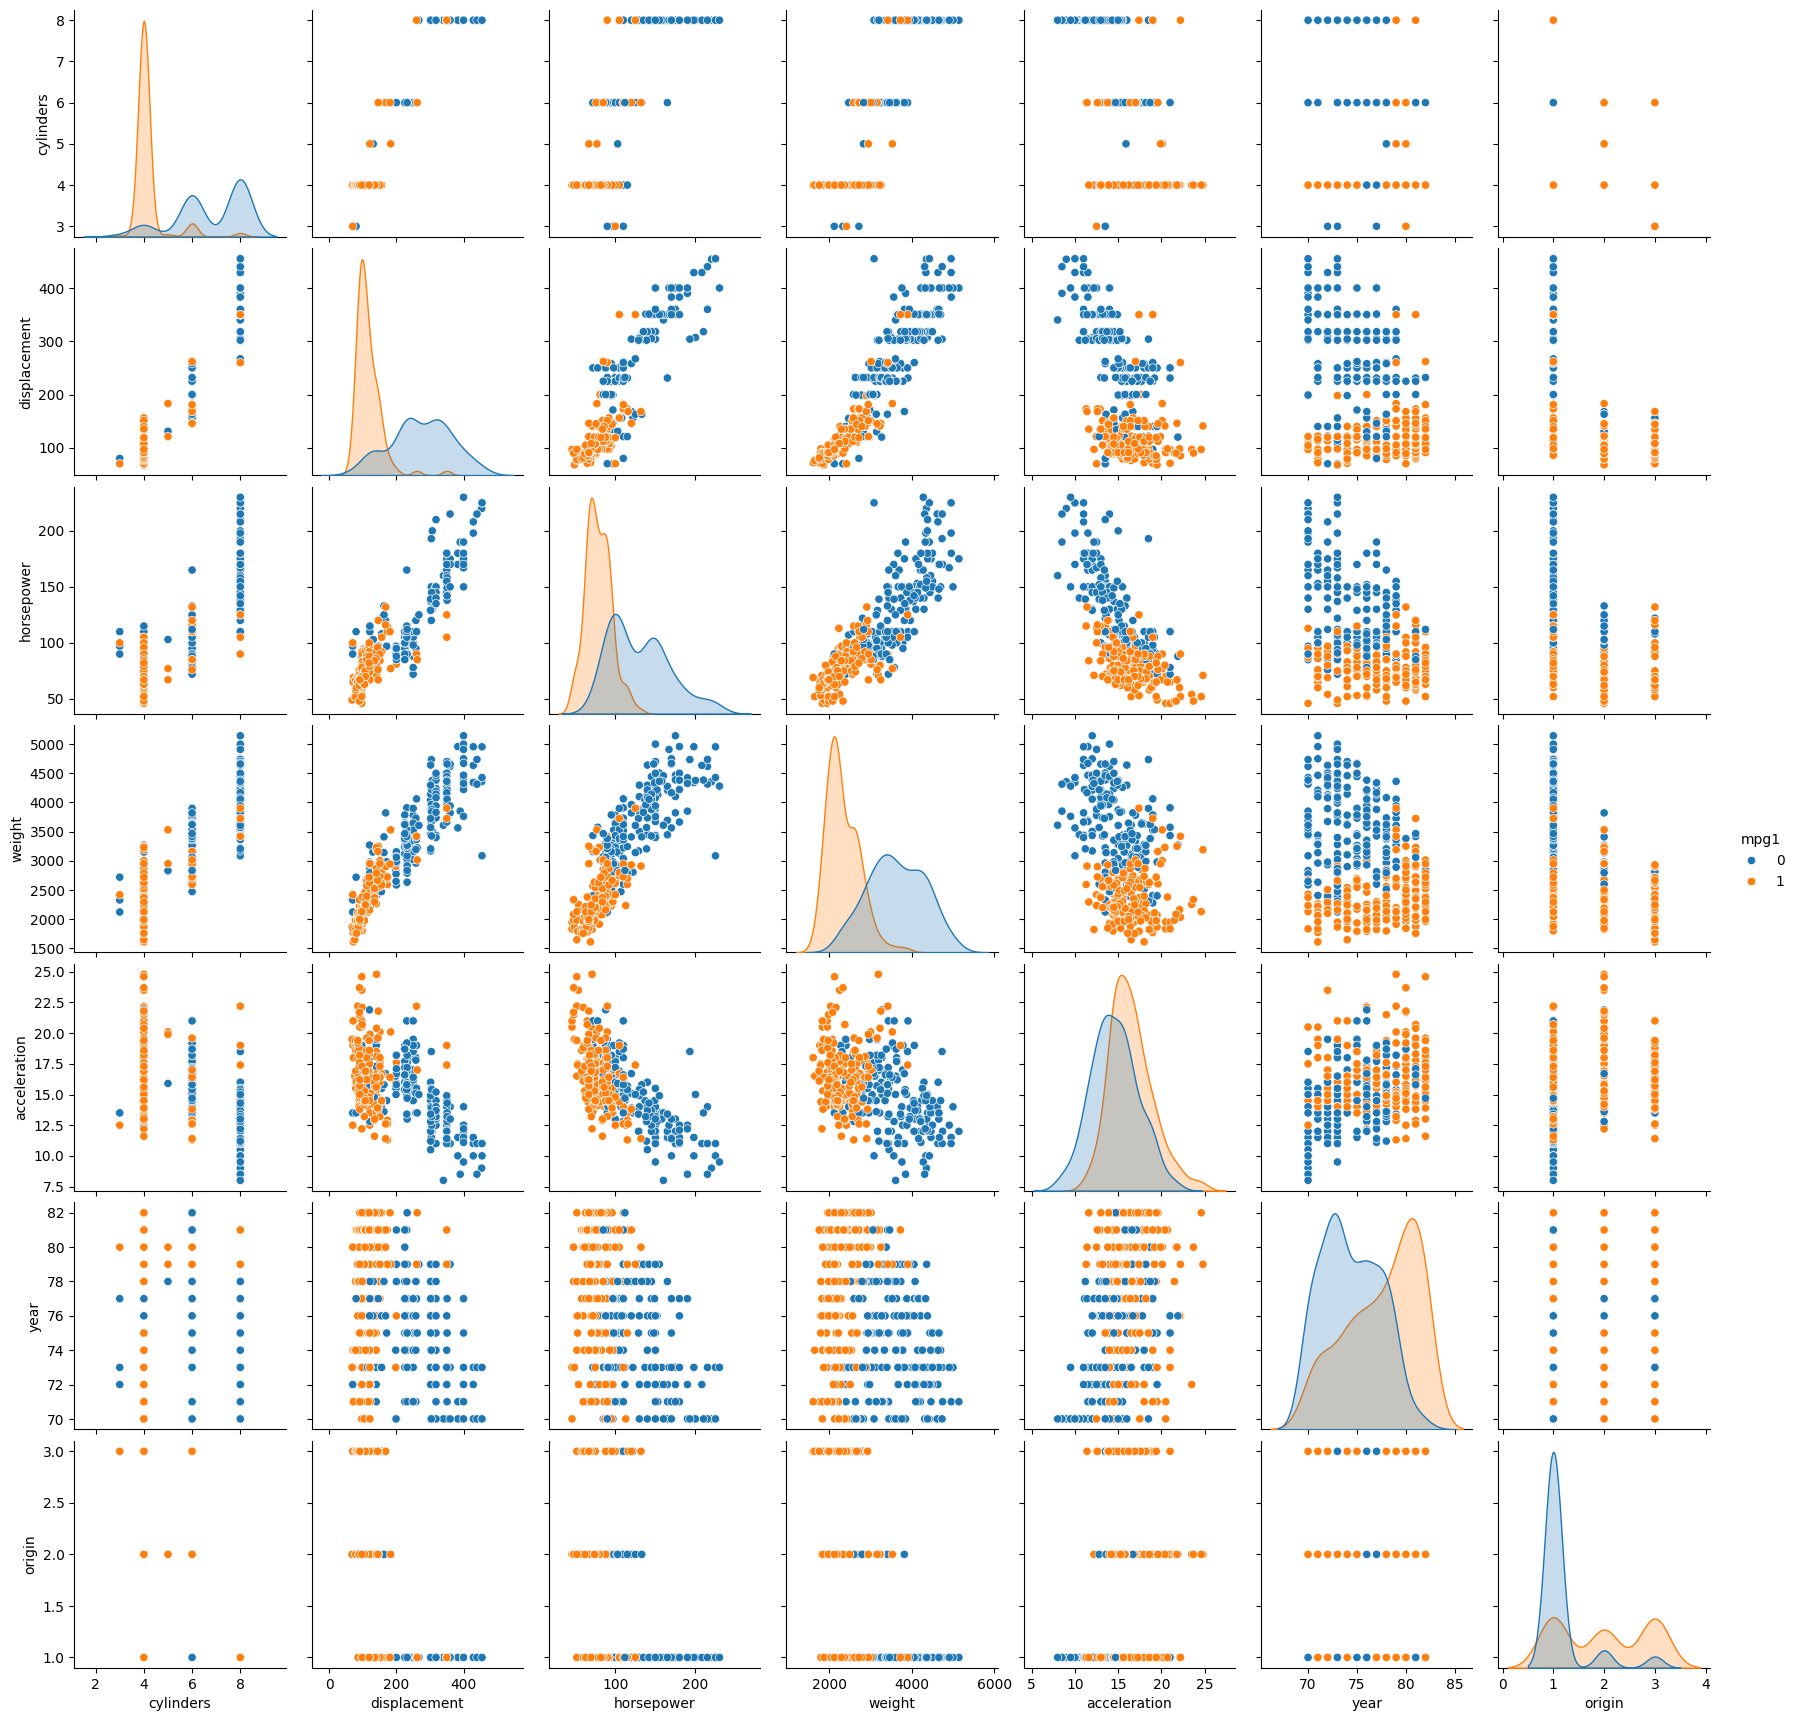

In [83]:
sns.pairplot(Auto,hue = 'mpg1')

(c) Разделить набор данных на обучающий и контрольный наборы.

In [90]:
Auto.columns[Auto.nunique() < 6]

Index(['cylinders', 'origin', 'mpg1'], dtype='object')

In [137]:
Auto = pd.get_dummies(data = Auto, columns = ['cylinders', 'origin'], drop_first = True)

In [139]:
allvars = Auto.columns.drop(['mpg1'])

In [140]:
allvars

Index(['displacement', 'horsepower', 'weight', 'acceleration', 'year',
       'cylinders_4', 'cylinders_5', 'cylinders_6', 'cylinders_8', 'origin_2',
       'origin_3'],
      dtype='object')

In [141]:
design = MS(allvars)

In [142]:
X = design.fit_transform(Auto)

In [143]:
y = Auto['mpg1']

In [144]:
X.head()

,intercept,displacement,horsepower,weight,acceleration,year,cylinders_4,cylinders_5,cylinders_6,cylinders_8,origin_2,origin_3
name,,,,,,,,,,,,
chevrolet chevelle malibu,1.0,307.0,130,3504,12.0,70,0.0,0.0,0.0,1.0,0.0,0.0
buick skylark 320,1.0,350.0,165,3693,11.5,70,0.0,0.0,0.0,1.0,0.0,0.0
plymouth satellite,1.0,318.0,150,3436,11.0,70,0.0,0.0,0.0,1.0,0.0,0.0
amc rebel sst,1.0,304.0,150,3433,12.0,70,0.0,0.0,0.0,1.0,0.0,0.0
ford torino,1.0,302.0,140,3449,10.5,70,0.0,0.0,0.0,1.0,0.0,0.0


In [164]:
y.head()

name
chevrolet chevelle malibu    0
buick skylark 320            0
plymouth satellite           0
amc rebel sst                0
ford torino                  0
Name: mpg1, dtype: int32

In [165]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

(d) Примените метод LDA к данным.

In [196]:
lda_model = LDA(store_covariance=True)
lda_result = lda_model.fit(X_train.drop('intercept', axis = 1),y_train)

In [201]:
pred = lda_result.predict(X_test.drop('intercept', axis = 1)) > 0.5

In [202]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

In [203]:
conf_mat = confusion_matrix(y_test, pred)

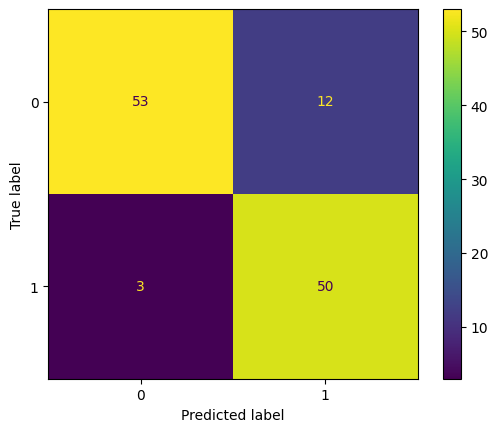

In [204]:
disp = ConfusionMatrixDisplay(conf_mat)
disp.plot()

In [207]:
print('Accuracy: ', (pred == y_test).mean())

Accuracy:  0.8728813559322034


(d) Теперь примените метод QDA к обучающим данным.

In [213]:
qda_model = QDA(store_covariance=True)
qda_result = qda_model.fit(X_train.drop('intercept', axis = 1),y_train)

In [214]:
pred = qda_result.predict(X_test.drop('intercept', axis = 1)) > 0.5

In [215]:
conf_mat = confusion_matrix(y_test, pred)

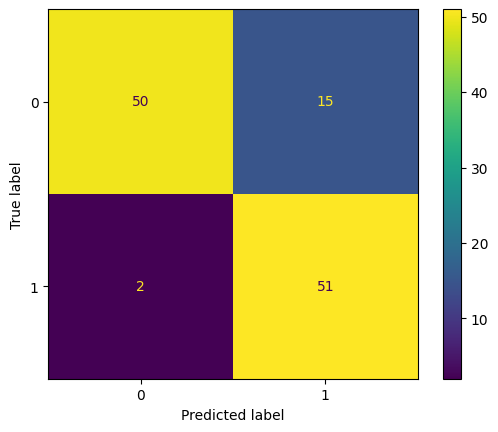

In [216]:
disp = ConfusionMatrixDisplay(conf_mat)
disp.plot()

In [217]:
print('Accuracy: ', (pred == y_test).mean())

Accuracy:  0.8559322033898306


(f) Повторите предыдущие упражнение с использованием линейного классификатора.

In [220]:
ln_model = sm.Logit(y_train, X_train)
ln_result = ln_model.fit()

Optimization terminated successfully.
         Current function value: 0.130493
         Iterations 10


In [222]:
pred = ln_result.predict(X_test) > 0.5

In [223]:
conf_mat = confusion_matrix(y_test, pred)

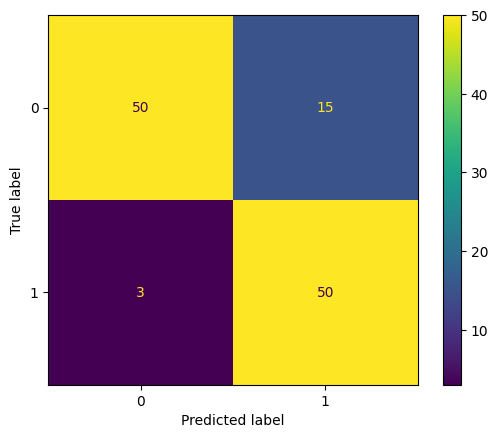

In [224]:
disp = ConfusionMatrixDisplay(conf_mat)
disp.plot()

In [225]:
print('Accuracy: ', (pred == y_test).mean())

Accuracy:  0.847457627118644


(h) Повторите с использованием наивного байеса.

In [226]:
NB = GaussianNB()
NB.fit(X_train.drop('intercept', axis = 1),y_train)

GaussianNB()

In [238]:
pred = NB.predict(X_test.drop('intercept', axis = 1)) > 0.5

In [239]:
conf_mat = confusion_matrix(y_test, pred)

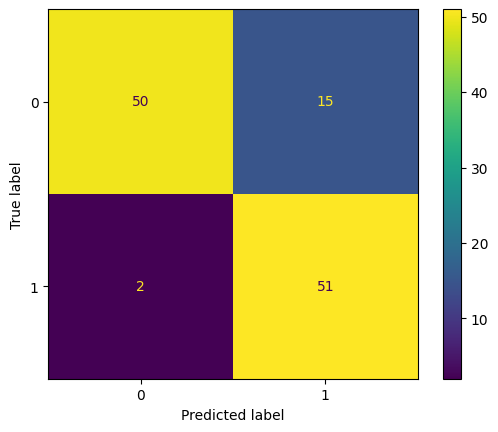

In [240]:
disp = ConfusionMatrixDisplay(conf_mat)
disp.plot()

In [237]:
print('Accuracy: ', (pred == y_test).mean())

Accuracy:  0.8559322033898306


In [241]:
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X_train.drop('intercept', axis = 1),y_train)

KNeighborsClassifier(n_neighbors=3)

(h) Повторите используя KNN.

In [242]:
pred = knn3.predict(X_test.drop('intercept', axis = 1)) > 0.5

In [243]:
conf_mat = confusion_matrix(y_test, pred)

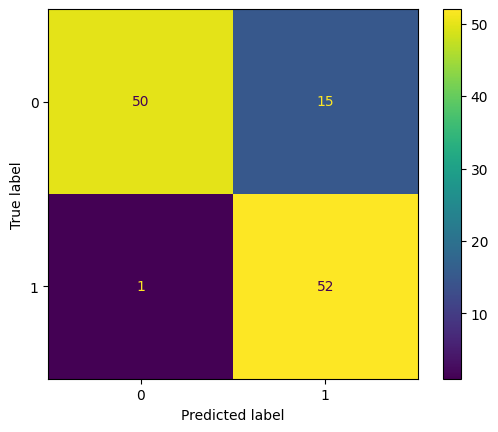

In [244]:
disp = ConfusionMatrixDisplay(conf_mat)
disp.plot()

In [245]:
print('Accuracy: ', (pred == y_test).mean())

Accuracy:  0.864406779661017
